# Final Analysis — All Methods, All Sizes (v2)

Streamlined analysis for paper writing. Sections:

- **A**: Load all judge files (auto-discovers `__g31` and non-`__g31` files)
- **B**: Method × size aggregations + % of teacher
- **C**: Full headline table (ALL methods, sorted by composite_5)
- **D**: Form-over-substance — paper's core finding
- **E**: Size scaling — MLP hypothesis evidence
- **F**: Phase 1 E-series only (clean baseline analysis)
- **G**: Phase 1 vs Phase 2 vs MLP ablation comparison
- **H**: Statistical significance (paired t-tests, 95% CIs)
- **I**: Failure case extraction
- **J**: Publication-ready plots

**Includes** MLP-LoRA E1 ablation (1.5B + 3B for now, 7B when ready).

## Section A — Load all judge files

In [24]:
# Cell A0: Config
import os, json, glob, re, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import display

# Show ALL rows in DataFrames (no truncation)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

PROJECT_DIR = r"C:\Users\adishalit1\Desktop\kd_project"
# PROJECT_DIR = os.path.expanduser("~/kd_project")

DATA_DIR = os.path.join(PROJECT_DIR, "data")
N_EVAL = 100

METRIC_COLS = ["decision_accuracy", "safety_score", "clinical_correctness",
               "completeness", "coherence", "format_compliance"]
COMP5_COLS = ["decision_accuracy", "safety_score", "clinical_correctness", "completeness", "coherence"]
REASONING_COLS = ["clinical_correctness", "completeness", "coherence"]

SIZE_MAP = {
    "qwen25_1p5b_base": "1.5B",
    "qwen25_3b_base":   "3B",
    "qwen25_7b_base":   "7B",
}
SIZE_ORDER = ["1.5B", "3B", "7B"]

# ── Method registration ──
METHOD_DISPLAY = {
    # Phase 1 E-series
    "e0_sft_adapted":              ("E0 SFT",              "E-series"),
    "e1_wsft_adapted":             ("E1 WSFT",             "E-series"),
    "e2_cwsft_adapted":            ("E2 CW-SFT",           "E-series"),
    "e3_cwwsft_adapted":           ("E3 CW-WSFT",          "E-series"),
    "e4_section_cw_wsft":          ("E4 Section CW-WSFT",  "E-series"),
    "e5a_decision_entropy_sft":    ("E5a Dec Entropy",     "E-series"),
    "e5b_explanation_entropy_sft": ("E5b Expl Entropy",    "E-series"),
    "e6_explanation_only_sft":     ("E6 Expl Only",        "E-series"),
    "e7_decision_only_sft":        ("E7 Dec Only",         "E-series"),
    # Phase 2 — M v1
    # "m1_additive_multi_loss":      ("M1 Additive",         "M v1"),
    # "m2_anti_curriculum":          ("M2 Anti-Curriculum",  "M v1"),
    # "m3_juggler":                  ("M3 Juggler",          "M v1"),
    # "m4_token_confidence_routing": ("M4 Token Conf",       "M v1"),
    # "m5_section_routed":           ("M5 Section Routed",   "M v1"),
    # "m6_lora_merging":             ("M6 LoRA Merge",       "M v1"),
    # "m7_warmstart_from_e7":        ("M7 Warmstart",        "M v1"),
    # Phase 2 — M v2
    **{f"m1v2_{c}": (f"M1v2 {c}", "M1v2 Additive") for c in ["A1"]},
    **{f"m2v2_{o}": (f"M2v2 {o}", "M2v2 Sequential") for o in ["WDE","WED","EDW","EWD"]},
    "m3v2_juggler":                ("M3v2 Juggler",        "M3v2 Juggler"),
    # "m4_metric_guided":            ("M4 Metric-Guided",    "M4 Metric-Guided"),
    # Baseline
    "raw_baseline":                ("Raw Baseline",        "Baseline"),
    # ── MLP-LoRA Ablation ──
    "e1_mlp":                      ("E1 + MLP-LoRA",       "MLP Ablation"),
}

print(f"Methods registered: {len(METHOD_DISPLAY)}")

Methods registered: 17


In [25]:
# Cell A1: Auto-discover all judge files
def find_judge_file(stub, prefer_g31=True):
    """Look for judge file. Prefer __g31 suffix if available."""
    candidates = [
        f"judge__{stub}__{N_EVAL}__g31.jsonl",
        f"judge__{stub}__{N_EVAL}.jsonl",
    ]
    if not prefer_g31:
        candidates.reverse()
    for c in candidates:
        path = os.path.join(DATA_DIR, c)
        if os.path.exists(path):
            return path
    return None

judge_files = {}
missing = []
for stub in METHOD_DISPLAY:
    path = find_judge_file(stub)
    if path:
        judge_files[stub] = path
    else:
        missing.append(stub)

teacher_path = None
for c in [f"judge__teacher__{N_EVAL}__g31.jsonl", f"judge__teacher__{N_EVAL}.jsonl"]:
    p = os.path.join(DATA_DIR, c)
    if os.path.exists(p):
        teacher_path = p
        break

print(f"✅ Found judge files: {len(judge_files)}")
print(f"✅ Teacher: {os.path.basename(teacher_path) if teacher_path else 'MISSING'}")
if missing:
    print(f"\n⚠️ Missing ({len(missing)}):")
    for m in missing:
        print(f"   {m}")

✅ Found judge files: 17
✅ Teacher: judge__teacher__100.jsonl


In [26]:
# Cell A2: Load teacher + master DataFrame
def load_judge_jsonl(path):
    out = []
    if not path or not os.path.exists(path):
        return out
    for line in open(path):
        try:
            obj = json.loads(line)
        except:
            continue
        if obj.get("status") != "ok":
            continue
        for mn, sc in obj.get("scores", {}).items():
            if isinstance(sc, dict):
                out.append((obj["id"], mn, sc))
    return out

# Teacher
teacher_rows = []
if teacher_path:
    for sid, mn, sc in load_judge_jsonl(teacher_path):
        if mn == "teacher":
            rec = {"id": sid}
            for c in METRIC_COLS:
                if c in sc:
                    rec[c] = float(sc[c])
            teacher_rows.append(rec)

teacher_df = pd.DataFrame(teacher_rows)
teacher_mean = {c: teacher_df[c].mean() if c in teacher_df else 0 for c in METRIC_COLS}
teacher_mean["reasoning_mean"] = np.mean([teacher_mean[c] for c in REASONING_COLS])
teacher_mean["composite_5"] = np.mean([teacher_mean[c] for c in COMP5_COLS])

print(f"=== TEACHER (Gemini 2.5 Pro), N={len(teacher_df)} ===")
for k in METRIC_COLS + ["reasoning_mean", "composite_5"]:
    print(f"  {k:25s}: {teacher_mean[k]:.3f}")

# All methods → master DataFrame
master_rows = []
for stub, path in judge_files.items():
    display_name, family = METHOD_DISPLAY[stub]
    for sid, mn, sc in load_judge_jsonl(path):
        if mn not in SIZE_MAP:
            continue
        rec = {"id": sid, "stub": stub, "method": display_name, "family": family,
               "model": mn, "size": SIZE_MAP[mn]}
        for c in METRIC_COLS:
            if c in sc:
                rec[c] = float(sc[c])
        master_rows.append(rec)

master_df = pd.DataFrame(master_rows)
master_df["reasoning_mean"] = master_df[REASONING_COLS].mean(axis=1)
master_df["composite_5"] = master_df[COMP5_COLS].mean(axis=1)
teacher_lookup = teacher_df.set_index("id") if not teacher_df.empty else None

print(f"\nMaster DataFrame: {len(master_df)} score rows, {master_df['method'].nunique()} methods")
print(f"Sizes per method:")
for m in sorted(master_df['method'].unique()):
    sizes = sorted(master_df[master_df['method']==m]['size'].unique(), key=lambda s: SIZE_ORDER.index(s))
    print(f"  {m:25s}: {sizes}")

=== TEACHER (Gemini 2.5 Pro), N=100 ===
  decision_accuracy        : 4.350
  safety_score             : 4.240
  clinical_correctness     : 4.220
  completeness             : 3.130
  coherence                : 3.650
  format_compliance        : 3.660
  reasoning_mean           : 3.667
  composite_5              : 3.918

Master DataFrame: 4970 score rows, 17 methods
Sizes per method:
  E0 SFT                   : ['1.5B', '3B', '7B']
  E1 + MLP-LoRA            : ['1.5B', '3B']
  E1 WSFT                  : ['1.5B', '3B', '7B']
  E2 CW-SFT                : ['1.5B', '3B', '7B']
  E3 CW-WSFT               : ['1.5B', '3B', '7B']
  E4 Section CW-WSFT       : ['1.5B', '3B', '7B']
  E5a Dec Entropy          : ['1.5B', '3B', '7B']
  E5b Expl Entropy         : ['1.5B', '3B', '7B']
  E6 Expl Only             : ['1.5B', '3B', '7B']
  E7 Dec Only              : ['1.5B', '3B', '7B']
  M1v2 A1                  : ['1.5B', '3B', '7B']
  M2v2 EDW                 : ['1.5B', '3B', '7B']
  M2v2 EWD           

## Section B — Method × Size Aggregations

In [27]:
# Cell B0: Compute aggregates and % of teacher
agg = master_df.groupby(["family", "method", "size"])[METRIC_COLS].mean()
agg["reasoning_mean"] = agg[REASONING_COLS].mean(axis=1)
agg["composite_5"] = agg[COMP5_COLS].mean(axis=1)

# Per-metric % of teacher
pct = agg.copy()
for c in METRIC_COLS + ["reasoning_mean", "composite_5"]:
    if teacher_mean[c] > 0:
        pct[c] = (agg[c] / teacher_mean[c] * 100)

agg = agg.round(3)
pct = pct.round(1)
print(f"Aggregated: {len(agg)} (method, size) combinations")
print(f"Teacher reference: composite_5={teacher_mean['composite_5']:.3f}, reasoning_mean={teacher_mean['reasoning_mean']:.3f}")

Aggregated: 50 (method, size) combinations
Teacher reference: composite_5=3.918, reasoning_mean=3.667


## Section C — Full Headline Table (ALL methods, sorted)

This is the master ranking. Read it top-to-bottom to see exactly where each
method falls and which family wins.

In [28]:
# Cell C0: Complete table — all methods at all sizes, sorted by composite_5
flat = agg.reset_index()
flat["pct_of_teacher"] = (flat["composite_5"] / teacher_mean["composite_5"] * 100).round(1)
flat_sorted = flat.sort_values("composite_5", ascending=False).reset_index(drop=True)

print("="*100)
print(f"  ALL METHODS — {len(flat_sorted)} rows, sorted by composite_5 (teacher = {teacher_mean['composite_5']:.3f})")
print("="*100)

display(flat_sorted[["family","method","size","composite_5","reasoning_mean","pct_of_teacher"] + METRIC_COLS])

flat_sorted.to_csv(os.path.join(DATA_DIR, "all_methods_ranked.csv"), index=False)
print(f"\n✅ Saved → all_methods_ranked.csv")

  ALL METHODS — 50 rows, sorted by composite_5 (teacher = 3.918)


,family,method,size,composite_5,reasoning_mean,pct_of_teacher,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance
0,MLP Ablation,E1 + MLP-LoRA,3B,3.878,3.713,99.0,4.300,3.950,2.970,3.730,4.440,4.970
1,E-series,E1 WSFT,7B,3.766,3.603,96.1,4.293,3.727,2.909,3.525,4.374,4.980
2,E-series,E7 Dec Only,7B,3.766,3.647,96.1,4.150,3.740,2.870,3.730,4.340,4.990
3,E-series,E5b Expl Entropy,7B,3.740,3.543,95.5,4.350,3.720,2.750,3.570,4.310,5.000
4,E-series,E3 CW-WSFT,7B,3.735,3.552,95.3,4.293,3.727,2.798,3.485,4.374,4.990
5,E-series,E5a Dec Entropy,7B,3.717,3.562,94.9,4.192,3.707,2.778,3.525,4.384,4.970
6,M2v2 Sequential,M2v2 WED,7B,3.716,3.530,94.8,4.300,3.690,2.760,3.470,4.360,4.950
7,E-series,E4 Section CW-WSFT,7B,3.685,3.529,94.1,4.192,3.646,2.778,3.465,4.343,4.990
8,E-series,E2 CW-SFT,7B,3.680,3.487,93.9,4.300,3.640,2.690,3.490,4.280,4.950
9,M2v2 Sequential,M2v2 EWD,7B,3.676,3.493,93.8,4.250,3.650,2.690,3.370,4.420,4.990



✅ Saved → all_methods_ranked.csv


In [29]:
# Cell C1: Best method per family per size — wide view
print("="*100)
print(f"  BEST METHOD PER (FAMILY × SIZE)")
print("="*100)

best_combos = []
for family in flat["family"].unique():
    for size in SIZE_ORDER:
        sub = flat[(flat["family"]==family) & (flat["size"]==size)]
        if sub.empty: continue
        best = sub.loc[sub["composite_5"].idxmax()]
        best_combos.append(best)

best_df = pd.DataFrame(best_combos).sort_values(["family","size"]).reset_index(drop=True)
display(best_df[["family","size","method","composite_5","reasoning_mean","pct_of_teacher"] + METRIC_COLS])

best_df.to_csv(os.path.join(DATA_DIR, "best_per_family_per_size.csv"), index=False)
print("\n✅ Saved → best_per_family_per_size.csv")

  BEST METHOD PER (FAMILY × SIZE)


,family,size,method,composite_5,reasoning_mean,pct_of_teacher,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance
0,Baseline,1.5B,Raw Baseline,2.038,1.807,52.0,2.900,1.870,0.690,1.850,2.880,1.12
1,Baseline,3B,Raw Baseline,2.878,2.630,73.5,3.650,2.850,1.910,2.390,3.590,3.10
2,Baseline,7B,Raw Baseline,3.352,3.083,85.6,4.150,3.360,2.390,2.770,4.090,2.48
3,E-series,1.5B,E7 Dec Only,3.008,2.583,76.8,4.350,2.940,1.680,2.570,3.500,0.01
4,E-series,3B,E7 Dec Only,3.398,3.197,86.7,4.100,3.300,2.240,3.350,4.000,4.99
5,E-series,7B,E1 WSFT,3.766,3.603,96.1,4.293,3.727,2.909,3.525,4.374,4.98
6,M1v2 Additive,1.5B,M1v2 A1,2.824,2.401,72.1,4.235,2.684,1.316,2.388,3.500,4.98
7,M1v2 Additive,3B,M1v2 A1,3.116,2.755,79.5,4.337,2.980,1.786,2.765,3.714,4.99
8,M1v2 Additive,7B,M1v2 A1,3.527,3.306,90.0,4.235,3.480,2.520,3.235,4.163,4.99
9,M2v2 Sequential,1.5B,M2v2 EWD,2.904,2.547,74.1,4.100,2.780,1.450,2.520,3.670,5.00



✅ Saved → best_per_family_per_size.csv


## Section D — Form-over-Substance (PAPER CORE)

Headline finding: students exceed teacher on structural metrics
(format / coherence / completeness) but lag on factual metrics
(clinical_correctness / safety_score). Pattern is consistent across all methods.

In [30]:
# Cell D0: Headline % of teacher table — all methods
print("="*100)
print(f"  % OF TEACHER PER METRIC — all methods at all sizes")
print(f"  (>100 means student beats teacher; <100 means student lags)")
print("="*100)

pct_flat = pct.reset_index().sort_values("composite_5", ascending=False).reset_index(drop=True)
display(pct_flat[["family","method","size"] + METRIC_COLS + ["reasoning_mean","composite_5"]])

pct_flat.to_csv(os.path.join(DATA_DIR, "pct_of_teacher_all.csv"), index=False)

  % OF TEACHER PER METRIC — all methods at all sizes
  (>100 means student beats teacher; <100 means student lags)


,family,method,size,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance,reasoning_mean,composite_5
0,MLP Ablation,E1 + MLP-LoRA,3B,98.9,93.2,70.4,119.2,121.6,135.8,101.3,99.0
1,E-series,E1 WSFT,7B,98.7,87.9,68.9,112.6,119.8,136.1,98.3,96.1
2,E-series,E7 Dec Only,7B,95.4,88.2,68.0,119.2,118.9,136.3,99.5,96.1
3,E-series,E5b Expl Entropy,7B,100.0,87.7,65.2,114.1,118.1,136.6,96.6,95.5
4,E-series,E3 CW-WSFT,7B,98.7,87.9,66.3,111.3,119.8,136.3,96.9,95.3
5,E-series,E5a Dec Entropy,7B,96.4,87.4,65.8,112.6,120.1,135.8,97.2,94.9
6,M2v2 Sequential,M2v2 WED,7B,98.9,87.0,65.4,110.9,119.5,135.2,96.3,94.8
7,E-series,E4 Section CW-WSFT,7B,96.4,86.0,65.8,110.7,119.0,136.3,96.2,94.0
8,E-series,E2 CW-SFT,7B,98.9,85.8,63.7,111.5,117.3,135.2,95.1,93.9
9,M2v2 Sequential,M2v2 EWD,7B,97.7,86.1,63.7,107.7,121.1,136.3,95.3,93.8


In [31]:
# Cell D1: Per-metric average across all methods
print("="*90)
print("  HOW EACH METRIC PERFORMS RELATIVE TO TEACHER (averaged across all methods × sizes)")
print("="*90)

mean_pct_per_metric = []
for c in METRIC_COLS:
    vals = (flat[c] / teacher_mean[c] * 100) if teacher_mean[c] > 0 else pd.Series([0])
    mean_pct_per_metric.append({
        "metric": c,
        "teacher_mean": round(teacher_mean[c], 3),
        "student_mean_pct": round(vals.mean(), 1),
        "student_min_pct": round(vals.min(), 1),
        "student_max_pct": round(vals.max(), 1),
        "n_methods_beating_teacher": int((flat[c] > teacher_mean[c]).sum()),
        "n_methods_total": len(flat),
    })
mpm_df = pd.DataFrame(mean_pct_per_metric)
display(mpm_df)

print("\n→ format_compliance, coherence, completeness usually >100% (students BEAT teacher)")
print("→ clinical_correctness, safety_score consistently <100% (students LAG)")
print("→ This is the form-over-substance gap")
mpm_df.to_csv(os.path.join(DATA_DIR, "form_over_substance_per_metric.csv"), index=False)

  HOW EACH METRIC PERFORMS RELATIVE TO TEACHER (averaged across all methods × sizes)


,metric,teacher_mean,student_mean_pct,student_min_pct,student_max_pct,n_methods_beating_teacher,n_methods_total
0,decision_accuracy,4.35,94.9,66.7,100.0,0,50
1,safety_score,4.24,74.2,44.1,93.2,0,50
2,clinical_correctness,4.22,47.0,16.4,70.4,0,50
3,completeness,3.13,93.7,59.1,119.2,18,50
4,coherence,3.65,106.8,78.9,121.6,36,50
5,format_compliance,3.66,126.1,0.0,136.6,45,50



→ format_compliance, coherence, completeness usually >100% (students BEAT teacher)
→ clinical_correctness, safety_score consistently <100% (students LAG)
→ This is the form-over-substance gap


## Section E — Size Scaling (MLP Hypothesis Evidence)

If facts live in frozen MLP layers, then clinical_correctness should scale with
frozen base model size, while format_compliance (handled by adapted attention) stays flat.

In [32]:
# Cell E0: Per-method size scaling for clinical_correctness vs format_compliance
print("="*100)
print("  SIZE SCALING — clinical_correctness vs format_compliance per method")
print("="*100)

# Build a wide table: one row per method, columns for each (size, metric)
scaling_rows = []
for method in sorted(flat["method"].unique()):
    mdf = flat[flat["method"] == method]
    if mdf["size"].nunique() < 2:
        continue
    rec = {"method": method, "family": mdf.iloc[0]["family"]}
    for size in SIZE_ORDER:
        srow = mdf[mdf["size"] == size]
        if not srow.empty:
            rec[f"{size}_clin"] = round(srow.iloc[0]["clinical_correctness"], 3)
            rec[f"{size}_fmt"] = round(srow.iloc[0]["format_compliance"], 3)
            rec[f"{size}_safe"] = round(srow.iloc[0]["safety_score"], 3)
    scaling_rows.append(rec)

scaling_df = pd.DataFrame(scaling_rows)
display(scaling_df)

# Average growth statistics
full = scaling_df.dropna(subset=["1.5B_clin","3B_clin","7B_clin"])
if not full.empty:
    print(f"\n=== AVERAGE GROWTH (1.5B → 7B) over {len(full)} methods with all 3 sizes ===")
    print(f"  clinical_correctness: +{(full['7B_clin']-full['1.5B_clin']).mean():.3f}  ← FACTS scale with frozen MLP")
    print(f"  format_compliance:    +{(full['7B_fmt']-full['1.5B_fmt']).mean():.3f}  ← STRUCTURE flat (attention LoRA saturates)")
    print(f"  safety_score:         +{(full['7B_safe']-full['1.5B_safe']).mean():.3f}  ← partly factual, partly structural")
scaling_df.to_csv(os.path.join(DATA_DIR, "size_scaling.csv"), index=False)

  SIZE SCALING — clinical_correctness vs format_compliance per method


,method,family,1.5B_clin,1.5B_fmt,1.5B_safe,3B_clin,3B_fmt,3B_safe,7B_clin,7B_fmt,7B_safe
0,E0 SFT,E-series,1.020,5.00,2.465,1.465,4.990,2.727,2.566,5.00,3.485
1,E1 + MLP-LoRA,MLP Ablation,2.620,4.97,3.600,2.970,4.970,3.950,NaN,NaN,NaN
2,E1 WSFT,E-series,1.424,4.98,2.869,1.949,4.949,3.131,2.909,4.98,3.727
3,E2 CW-SFT,E-series,1.450,4.96,2.870,1.800,4.940,3.070,2.690,4.95,3.640
4,E3 CW-WSFT,E-series,1.293,4.98,2.677,1.970,4.980,3.182,2.798,4.99,3.727
5,E4 Section CW-WSFT,E-series,1.525,4.99,2.727,1.808,4.990,3.020,2.778,4.99,3.646
6,E5a Dec Entropy,E-series,1.404,4.97,2.808,1.929,4.939,3.172,2.778,4.97,3.707
7,E5b Expl Entropy,E-series,1.480,5.00,2.970,2.070,4.940,3.280,2.750,5.00,3.720
8,E6 Expl Only,E-series,1.653,0.00,2.745,2.184,4.990,3.122,2.612,5.00,3.571
9,E7 Dec Only,E-series,1.680,0.01,2.940,2.240,4.990,3.300,2.870,4.99,3.740



=== AVERAGE GROWTH (1.5B → 7B) over 16 methods with all 3 sizes ===
  clinical_correctness: +1.328  ← FACTS scale with frozen MLP
  format_compliance:    +0.710  ← STRUCTURE flat (attention LoRA saturates)
  safety_score:         +0.927  ← partly factual, partly structural


## Section F — Phase 1 E-Series Only (clean baseline view)

Strips out all M-series and ablation methods so you can see Phase 1 in isolation.
Useful for paper §5 (Single-Objective Distillation) where you only discuss E-methods.

In [33]:
# Cell F0: Phase 1 only — all 9 E-methods at all 3 sizes
phase1 = flat[flat["family"] == "E-series"].sort_values("composite_5", ascending=False).reset_index(drop=True)

print("="*100)
print(f"  PHASE 1 (E-SERIES ONLY) — {len(phase1)} rows, sorted by composite_5")
print("="*100)
display(phase1[["method","size","composite_5","reasoning_mean","pct_of_teacher"] + METRIC_COLS])

phase1.to_csv(os.path.join(DATA_DIR, "phase1_only_ranked.csv"), index=False)

  PHASE 1 (E-SERIES ONLY) — 27 rows, sorted by composite_5


,method,size,composite_5,reasoning_mean,pct_of_teacher,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance
0,E1 WSFT,7B,3.766,3.603,96.1,4.293,3.727,2.909,3.525,4.374,4.980
1,E7 Dec Only,7B,3.766,3.647,96.1,4.150,3.740,2.870,3.730,4.340,4.990
2,E5b Expl Entropy,7B,3.740,3.543,95.5,4.350,3.720,2.750,3.570,4.310,5.000
3,E3 CW-WSFT,7B,3.735,3.552,95.3,4.293,3.727,2.798,3.485,4.374,4.990
4,E5a Dec Entropy,7B,3.717,3.562,94.9,4.192,3.707,2.778,3.525,4.384,4.970
5,E4 Section CW-WSFT,7B,3.685,3.529,94.1,4.192,3.646,2.778,3.465,4.343,4.990
6,E2 CW-SFT,7B,3.680,3.487,93.9,4.300,3.640,2.690,3.490,4.280,4.950
7,E6 Expl Only,7B,3.622,3.486,92.4,4.082,3.571,2.612,3.561,4.286,5.000
8,E0 SFT,7B,3.535,3.350,90.2,4.141,3.485,2.566,3.293,4.192,5.000
9,E7 Dec Only,3B,3.398,3.197,86.7,4.100,3.300,2.240,3.350,4.000,4.990


In [34]:
# Cell F1: Phase 1 — top method per size + per-metric leader
print("="*100)
print("  PHASE 1 — best E-method per size (composite_5 winner)")
print("="*100)
for size in SIZE_ORDER:
    sub = phase1[phase1["size"] == size]
    if sub.empty: continue
    best = sub.iloc[0]
    print(f"\n  {size}: 🏆 {best['method']}  composite_5={best['composite_5']:.3f}  ({best['pct_of_teacher']}% of teacher)")

print("\n" + "="*100)
print("  PHASE 1 — best E-method per metric (across all sizes)")
print("="*100)
print(f"{'Metric':<25s} {'Best method':<25s} {'Size':<6s} {'Score':<8s} {'% Teacher':<10s}")
print("-"*80)
for c in METRIC_COLS:
    leader_idx = phase1[c].idxmax()
    leader = phase1.loc[leader_idx]
    pct_t = (leader[c] / teacher_mean[c] * 100) if teacher_mean[c] > 0 else 0
    print(f"{c:<25s} {leader['method']:<25s} {leader['size']:<6s} {leader[c]:<8.3f} {pct_t:<10.1f}")

print("\n→ No single method wins all metrics — confirming the multi-objective motivation for Phase 2")

  PHASE 1 — best E-method per size (composite_5 winner)

  1.5B: 🏆 E7 Dec Only  composite_5=3.008  (76.8% of teacher)

  3B: 🏆 E7 Dec Only  composite_5=3.398  (86.7% of teacher)

  7B: 🏆 E1 WSFT  composite_5=3.766  (96.1% of teacher)

  PHASE 1 — best E-method per metric (across all sizes)
Metric                    Best method               Size   Score    % Teacher 
--------------------------------------------------------------------------------
decision_accuracy         E5b Expl Entropy          7B     4.350    100.0     
safety_score              E7 Dec Only               7B     3.740    88.2      
clinical_correctness      E1 WSFT                   7B     2.909    68.9      
completeness              E7 Dec Only               7B     3.730    119.2     
coherence                 E5a Dec Entropy           7B     4.384    120.1     
format_compliance         E5b Expl Entropy          7B     5.000    136.6     

→ No single method wins all metrics — confirming the multi-objective motiv

In [35]:
# Cell F2: Phase 1 — full per-metric % of teacher table
phase1_pct = pct.reset_index()
phase1_pct = phase1_pct[phase1_pct["family"] == "E-series"].sort_values("composite_5", ascending=False).reset_index(drop=True)

print("="*100)
print("  PHASE 1 — % of teacher per metric (Phase 1 form-over-substance pattern)")
print("="*100)
display(phase1_pct[["method","size"] + METRIC_COLS + ["reasoning_mean","composite_5"]])

  PHASE 1 — % of teacher per metric (Phase 1 form-over-substance pattern)


,method,size,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance,reasoning_mean,composite_5
0,E1 WSFT,7B,98.7,87.9,68.9,112.6,119.8,136.1,98.3,96.1
1,E7 Dec Only,7B,95.4,88.2,68.0,119.2,118.9,136.3,99.5,96.1
2,E5b Expl Entropy,7B,100.0,87.7,65.2,114.1,118.1,136.6,96.6,95.5
3,E3 CW-WSFT,7B,98.7,87.9,66.3,111.3,119.8,136.3,96.9,95.3
4,E5a Dec Entropy,7B,96.4,87.4,65.8,112.6,120.1,135.8,97.2,94.9
5,E4 Section CW-WSFT,7B,96.4,86.0,65.8,110.7,119.0,136.3,96.2,94.0
6,E2 CW-SFT,7B,98.9,85.8,63.7,111.5,117.3,135.2,95.1,93.9
7,E6 Expl Only,7B,93.8,84.2,61.9,113.8,117.4,136.6,95.1,92.5
8,E0 SFT,7B,95.2,82.2,60.8,105.2,114.8,136.6,91.4,90.2
9,E7 Dec Only,3B,94.3,77.8,53.1,107.0,109.6,136.3,87.2,86.7


## Section G — Phase 1 vs Phase 2 vs MLP Ablation

Did Phase 2 multi-objective methods actually beat the best Phase 1 baseline?
Did MLP-LoRA improve over the original LoRA config? One table to answer both.

In [36]:
# Cell G0: Best Phase 1 vs best Phase 2 vs MLP-LoRA, per size
PHASE1_FAMILY = ["E-series"]
PHASE2_FAMILIES = ["M v1", "M1v2 Additive", "M2v2 Sequential", "M3v2 Juggler", "M4 Metric-Guided"]
ABLATION_FAMILIES = ["MLP Ablation"]
BASELINE_FAMILIES = ["Baseline"]

print("="*100)
print("  PHASE 1 vs PHASE 2 vs MLP — best of each per size")
print("="*100)

comparison_rows = []
for size in SIZE_ORDER:
    for label, families in [
        ("Baseline (no train)", BASELINE_FAMILIES),
        ("Phase 1 best", PHASE1_FAMILY),
        ("Phase 2 best", PHASE2_FAMILIES),
        ("MLP-LoRA Ablation", ABLATION_FAMILIES),
    ]:
        sub = flat[(flat["family"].isin(families)) & (flat["size"] == size)]
        if sub.empty: continue
        best = sub.loc[sub["composite_5"].idxmax()]
        rec = {
            "size": size,
            "phase": label,
            "method": best["method"],
            "composite_5": round(best["composite_5"], 3),
            "pct_of_teacher": round(best["pct_of_teacher"], 1),
            "clinical_correctness": round(best["clinical_correctness"], 3),
            "safety_score": round(best["safety_score"], 3),
            "format_compliance": round(best["format_compliance"], 3),
            "completeness": round(best["completeness"], 3),
            "coherence": round(best["coherence"], 3),
        }
        comparison_rows.append(rec)

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

print("\n→ Phase 2 best vs Phase 1 best: shows whether multi-objective actually helps")
print("→ MLP-LoRA vs Phase 1 best: shows whether MLP targets fix the form-over-substance gap")
comparison_df.to_csv(os.path.join(DATA_DIR, "phase_comparison.csv"), index=False)

  PHASE 1 vs PHASE 2 vs MLP — best of each per size


,size,phase,method,composite_5,pct_of_teacher,clinical_correctness,safety_score,format_compliance,completeness,coherence
0,1.5B,Baseline (no train),Raw Baseline,2.038,52.0,0.690,1.870,1.12,1.850,2.880
1,1.5B,Phase 1 best,E7 Dec Only,3.008,76.8,1.680,2.940,0.01,2.570,3.500
2,1.5B,Phase 2 best,M2v2 EWD,2.904,74.1,1.450,2.780,5.00,2.520,3.670
3,1.5B,MLP-LoRA Ablation,E1 + MLP-LoRA,3.644,93.0,2.620,3.600,4.97,3.480,4.270
4,3B,Baseline (no train),Raw Baseline,2.878,73.5,1.910,2.850,3.10,2.390,3.590
5,3B,Phase 1 best,E7 Dec Only,3.398,86.7,2.240,3.300,4.99,3.350,4.000
6,3B,Phase 2 best,M2v2 EWD,3.198,81.6,1.870,3.220,5.00,2.760,3.940
7,3B,MLP-LoRA Ablation,E1 + MLP-LoRA,3.878,99.0,2.970,3.950,4.97,3.730,4.440
8,7B,Baseline (no train),Raw Baseline,3.352,85.6,2.390,3.360,2.48,2.770,4.090
9,7B,Phase 1 best,E1 WSFT,3.766,96.1,2.909,3.727,4.98,3.525,4.374



→ Phase 2 best vs Phase 1 best: shows whether multi-objective actually helps
→ MLP-LoRA vs Phase 1 best: shows whether MLP targets fix the form-over-substance gap


In [37]:
# Cell G1: MLP-LoRA delta vs original E1 (paired metric-by-metric)
mlp_rows = flat[flat["family"] == "MLP Ablation"]
e1_rows = flat[flat["method"] == "E1 WSFT"]

if mlp_rows.empty:
    print("⏩ MLP ablation data not loaded — run e1_mlp judging first")
else:
    print("="*100)
    print("  MLP-LoRA E1 vs original E1 — per-metric delta")
    print(f"  (Hypothesis: clinical_correctness improves a lot, format_compliance stays same)")
    print("="*100)
    
    delta_rows = []
    for size in SIZE_ORDER:
        mlp = mlp_rows[mlp_rows["size"] == size]
        e1 = e1_rows[e1_rows["size"] == size]
        if mlp.empty or e1.empty: continue
        m_row = mlp.iloc[0]
        e_row = e1.iloc[0]
        rec = {"size": size}
        for c in METRIC_COLS + ["reasoning_mean", "composite_5"]:
            rec[f"{c}_e1"] = round(e_row[c], 3)
            rec[f"{c}_mlp"] = round(m_row[c], 3)
            rec[f"{c}_delta"] = round(m_row[c] - e_row[c], 3)
        delta_rows.append(rec)
    
    if delta_rows:
        ddf = pd.DataFrame(delta_rows).set_index("size")
        # Show in a readable layout
        for size in ddf.index:
            print(f"\n--- {size} ---")
            row = ddf.loc[size]
            print(f"{'Metric':<25s} {'E1':>8s} {'E1+MLP':>10s} {'Δ':>8s}")
            print("-"*55)
            for c in METRIC_COLS + ["reasoning_mean", "composite_5"]:
                e_val = row[f"{c}_e1"]
                m_val = row[f"{c}_mlp"]
                d_val = row[f"{c}_delta"]
                arrow = "↑" if d_val > 0.05 else "↓" if d_val < -0.05 else "·"
                print(f"{c:<25s} {e_val:>8.3f} {m_val:>10.3f} {d_val:>+7.3f} {arrow}")
        ddf.to_csv(os.path.join(DATA_DIR, "mlp_vs_e1_delta.csv"))

  MLP-LoRA E1 vs original E1 — per-metric delta
  (Hypothesis: clinical_correctness improves a lot, format_compliance stays same)

--- 1.5B ---
Metric                          E1     E1+MLP        Δ
-------------------------------------------------------
decision_accuracy            4.192      4.250  +0.058 ↑
safety_score                 2.869      3.600  +0.731 ↑
clinical_correctness         1.424      2.620  +1.196 ↑
completeness                 2.566      3.480  +0.914 ↑
coherence                    3.545      4.270  +0.725 ↑
format_compliance            4.980      4.970  -0.010 ·
reasoning_mean               2.512      3.457  +0.945 ↑
composite_5                  2.919      3.644  +0.725 ↑

--- 3B ---
Metric                          E1     E1+MLP        Δ
-------------------------------------------------------
decision_accuracy            4.242      4.300  +0.058 ↑
safety_score                 3.131      3.950  +0.819 ↑
clinical_correctness         1.949      2.970  +1.021 ↑
comple

## Section H — Statistical Significance

In [38]:
# Cell H0: Paired t-tests between top 5 methods at 7B
from scipy import stats

top5 = flat[flat["size"] == "7B"].sort_values("composite_5", ascending=False).head(5)
top_method_names = top5["method"].tolist()
print(f"Top 5 at 7B: {top_method_names}")

def get_q_scores(method_name, size, metric):
    sub = master_df[(master_df["method"] == method_name) & (master_df["size"] == size)]
    return sub.set_index("id")[metric]

# Pairwise: top1 vs each other
top1 = top_method_names[0]
top1_scores = get_q_scores(top1, "7B", "composite_5")

print(f"\nBaseline: {top1} 7B (mean comp5 = {top1_scores.mean():.3f})")
print(f"\n{'Comparison':<55s} {'mean':>8s} {'delta':>8s} {'p-value':>10s} {'sig':>5s}")
print("-"*90)
for other in top_method_names[1:]:
    other_scores = get_q_scores(other, "7B", "composite_5")
    common = top1_scores.index.intersection(other_scores.index)
    if len(common) < 5: continue
    a = top1_scores.loc[common]
    b = other_scores.loc[common]
    t, p = stats.ttest_rel(a, b)
    delta = a.mean() - b.mean()
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
    print(f"{top1[:25]:<25s} vs {other[:25]:<25s}  {b.mean():>8.3f} {delta:>+8.3f} {p:>10.4f} {sig:>5s}")

Top 5 at 7B: ['E1 WSFT', 'E7 Dec Only', 'E5b Expl Entropy', 'E3 CW-WSFT', 'E5a Dec Entropy']

Baseline: E1 WSFT 7B (mean comp5 = 3.766)

Comparison                                                  mean    delta    p-value   sig
------------------------------------------------------------------------------------------
E1 WSFT                   vs E7 Dec Only                   3.774   -0.008     0.9337  n.s.
E1 WSFT                   vs E5b Expl Entropy              3.739   +0.026     0.6947  n.s.
E1 WSFT                   vs E3 CW-WSFT                    3.739   +0.014     0.8229  n.s.
E1 WSFT                   vs E5a Dec Entropy               3.716   +0.037     0.6100  n.s.


In [39]:
# Cell H1: 95% CIs for top 5 methods (7B)
print("="*100)
print("  95% CONFIDENCE INTERVALS — top 5 at 7B, per metric")
print("="*100)

ci_rows = []
for method in top_method_names:
    sub = master_df[(master_df["method"] == method) & (master_df["size"] == "7B")]
    if sub.empty: continue
    rec = {"method": method}
    for c in METRIC_COLS + ["composite_5", "reasoning_mean"]:
        vals = sub[c].dropna()
        if len(vals) < 2: continue
        mean = vals.mean()
        sem = vals.std() / np.sqrt(len(vals))
        ci95 = 1.96 * sem
        rec[c] = f"{mean:.2f} ±{ci95:.2f}"
    ci_rows.append(rec)

ci_df = pd.DataFrame(ci_rows).set_index("method")
display(ci_df)
ci_df.to_csv(os.path.join(DATA_DIR, "top_methods_with_ci.csv"))

  95% CONFIDENCE INTERVALS — top 5 at 7B, per metric


,decision_accuracy,safety_score,clinical_correctness,completeness,coherence,format_compliance,composite_5,reasoning_mean
method,,,,,,,,
E1 WSFT,4.29 ±0.34,3.73 ±0.29,2.91 ±0.35,3.53 ±0.28,4.37 ±0.16,4.98 ±0.03,3.77 ±0.25,3.60 ±0.24
E7 Dec Only,4.15 ±0.37,3.74 ±0.27,2.87 ±0.34,3.73 ±0.23,4.34 ±0.14,4.99 ±0.02,3.77 ±0.22,3.65 ±0.21
E5b Expl Entropy,4.35 ±0.33,3.72 ±0.28,2.75 ±0.34,3.57 ±0.26,4.31 ±0.17,5.00 ±0.00,3.74 ±0.23,3.54 ±0.23
E3 CW-WSFT,4.29 ±0.34,3.73 ±0.27,2.80 ±0.35,3.48 ±0.26,4.37 ±0.15,4.99 ±0.02,3.74 ±0.23,3.55 ±0.23
E5a Dec Entropy,4.19 ±0.36,3.71 ±0.28,2.78 ±0.35,3.53 ±0.26,4.38 ±0.14,4.97 ±0.03,3.72 ±0.24,3.56 ±0.23


## Section I — Failure Case Extraction

Pull questions where even the best student got facts wrong, for paper appendix annotation.

In [40]:
# Cell I0: Find lowest clinical_correctness questions
per_q_clin = master_df.groupby("id").agg(
    max_clin=("clinical_correctness", "max"),
    mean_clin=("clinical_correctness", "mean"),
).round(3)

if teacher_lookup is not None:
    per_q_clin = per_q_clin.join(teacher_lookup[["clinical_correctness"]].rename(columns={"clinical_correctness": "teacher_clin"}))
    per_q_clin["gap_to_teacher"] = (per_q_clin["teacher_clin"] - per_q_clin["max_clin"]).round(3)

worst = per_q_clin.sort_values("max_clin").head(10)
print("="*90)
print("  10 WORST QUESTIONS BY MAX CLINICAL_CORRECTNESS")
print("  (questions where even the best student method got facts wrong)")
print("="*90)
display(worst)

  10 WORST QUESTIONS BY MAX CLINICAL_CORRECTNESS
  (questions where even the best student method got facts wrong)


,max_clin,mean_clin,teacher_clin,gap_to_teacher
id,,,,
c1f258c4caf2,0.0,0.000,1.0,1.0
b70d0a5f1994,1.0,0.160,3.0,2.0
df5f0d093ff8,1.0,0.020,5.0,4.0
0b9f8380ccf2,2.0,0.300,3.0,1.0
eafd85407444,2.0,0.681,1.0,-1.0
704ac1a7e86d,2.0,0.300,0.0,-2.0
51e9a1e2199a,3.0,0.860,1.0,-2.0
11c68756bfcc,3.0,0.300,3.0,0.0
84865f14a3a3,3.0,1.100,5.0,2.0


In [41]:
# Cell I1: Pull full prompts + best answers for top 5 worst
def find_inference_file(stub):
    for c in [f"{stub}_inference_{N_EVAL}_TESTONLY.json"]:
        path = os.path.join(DATA_DIR, c)
        if os.path.exists(path):
            return path
    return None

teacher_inf_path = os.path.join(DATA_DIR, f"teacher_inference_{N_EVAL}_TESTONLY.json")
teacher_inf = None
if os.path.exists(teacher_inf_path):
    with open(teacher_inf_path) as f:
        teacher_inf = json.load(f)

N_FAILURE_CASES = 5
worst_ids = worst.head(N_FAILURE_CASES).index.tolist()
failure_cases = []

for qid in worst_ids:
    case = {"id": qid, "stats": worst.loc[qid].to_dict()}
    q_rows = master_df[master_df["id"] == qid].sort_values("clinical_correctness", ascending=False)
    if not q_rows.empty:
        top = q_rows.iloc[0]
        case["best_method"] = top["method"]
        case["best_size"] = top["size"]
        case["best_clin"] = round(top["clinical_correctness"], 2)
        inf_path = find_inference_file(top["stub"])
        if inf_path:
            with open(inf_path) as f:
                inf_data = json.load(f)
            for sample in inf_data.get("samples", []):
                if sample["id"] == qid:
                    case["prompt"] = sample.get("prompt", "")[:400] + "..."
                    if top["model"] in sample.get("outputs", {}):
                        case["best_answer"] = sample["outputs"][top["model"]].get("answer", "")[:500]
                    break
    if teacher_inf:
        for sample in teacher_inf.get("samples", []):
            if sample["id"] == qid:
                case["teacher_answer"] = sample.get("outputs", {}).get("teacher", {}).get("answer", "")[:500]
                break
    failure_cases.append(case)

for i, case in enumerate(failure_cases):
    print(f"\n{'='*90}\n  CASE {i+1}: Question {case['id']}\n{'='*90}")
    print(f"  Best method: {case.get('best_method', '?')} ({case.get('best_size', '?')})")
    print(f"  Best clin: {case.get('best_clin', 0):.2f}  |  Teacher clin: {case.get('stats', {}).get('teacher_clin', 'N/A')}")
    print(f"\n  PROMPT:\n  {case.get('prompt', 'N/A')[:300]}")
    print(f"\n  BEST STUDENT ANSWER:\n  {case.get('best_answer', 'N/A')[:400]}")
    print(f"\n  TEACHER ANSWER:\n  {case.get('teacher_answer', 'N/A')[:400]}")

with open(os.path.join(DATA_DIR, "failure_cases.json"), "w", encoding="utf-8") as f:
    json.dump(failure_cases, f, ensure_ascii=False, indent=2)
print(f"\n\n✅ Saved {len(failure_cases)} → failure_cases.json")
print("Read these and write 1-2 sentence categorizations for the paper appendix.")


  CASE 1: Question c1f258c4caf2
  Best method: E0 SFT (3B)
  Best clin: 0.00  |  Teacher clin: 1.0

  PROMPT:
  QUESTION:
You are a clinical pharmacology decision assistant.
Always base your answers on verified medical knowledge, and avoid speculation.

Patient profile:
- Age: 64
- Sex: Female
- Weight: 74 kg
- Height: 163 cm
- BMI: 27.9
- Renal function: Mild impairment (eGFR 60–89)
- Liver function: Cirrhos

  BEST STUDENT ANSWER:
  Decision: Unsafe
Explanation: This combination is unsafe due to a significant pharmacokinetic interaction. Fluconazole is a potent inhibitor of the CYP2C9 enzyme, which is the primary metabolic pathway for lithium. This inhibition will cause the accumulation of lithium, leading to a high risk of toxicity. The patient's moderate liver cirrhosis (Child-Pugh B) further impairs the metabolism of lithi

  TEACHER ANSWER:
  Decision: Unsafe
Explanation: The co-administration of fluconazole and lithium is unsafe due to a significant risk of lithium toxicity. Fl

## Section J — Plots

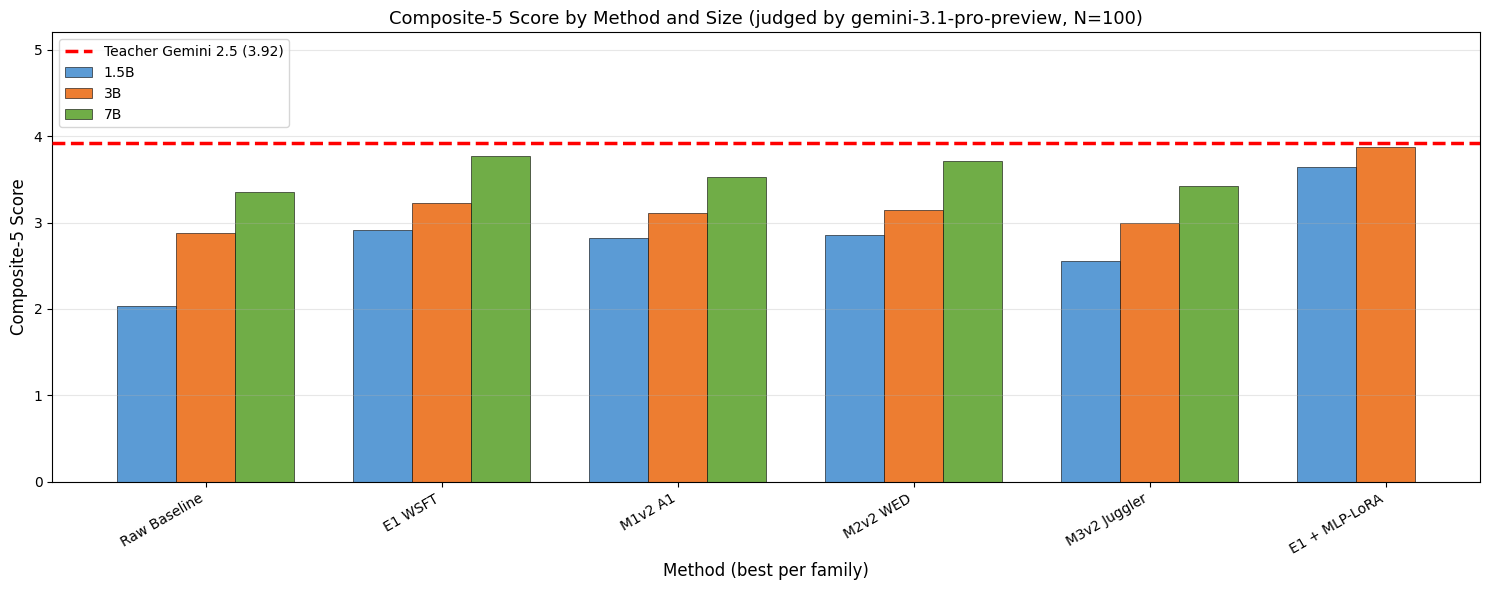

Saved: FIG1_composite5_by_method_size.png


In [42]:
# Cell J0: Headline figure — composite_5 by best-of-family × size
plot_methods = []
for fam in ["Baseline", "E-series", "M v1", "M1v2 Additive", "M2v2 Sequential",
            "M3v2 Juggler", "M4 Metric-Guided", "MLP Ablation"]:
    fdf = flat[flat["family"] == fam]
    if fdf.empty: continue
    best = fdf.sort_values("composite_5", ascending=False).iloc[0]
    plot_methods.append(best["method"])

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(plot_methods))
width = 0.25
colors = {"1.5B": "#5B9BD5", "3B": "#ED7D31", "7B": "#70AD47"}

for i, size in enumerate(SIZE_ORDER):
    values = []
    for m in plot_methods:
        sub = flat[(flat["method"] == m) & (flat["size"] == size)]
        values.append(sub.iloc[0]["composite_5"] if not sub.empty else np.nan)
    ax.bar(x + (i-1)*width, values, width, label=size, color=colors[size], edgecolor="black", linewidth=0.4)

ax.axhline(y=teacher_mean["composite_5"], color="red", linestyle="--", linewidth=2.5,
           label=f"Teacher Gemini 2.5 ({teacher_mean['composite_5']:.2f})", zorder=10)
ax.set_xlabel("Method (best per family)", fontsize=12)
ax.set_ylabel("Composite-5 Score", fontsize=12)
ax.set_title(f"Composite-5 Score by Method and Size (judged by gemini-3.1-pro-preview, N={N_EVAL})", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(plot_methods, rotation=30, ha="right")
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 5.2)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG1_composite5_by_method_size.png"), dpi=150)
plt.show()
print("Saved: FIG1_composite5_by_method_size.png")

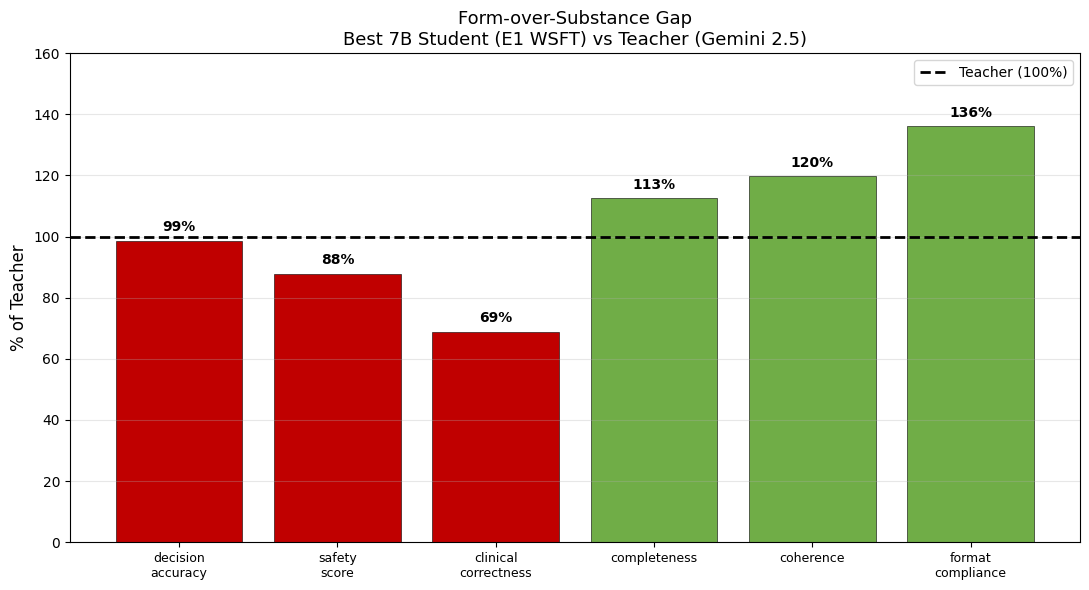

Saved: FIG2_form_over_substance.png


In [43]:
# Cell J1: Form-over-substance — best 7B vs teacher per metric
best_7b = flat[flat["size"] == "7B"].sort_values("composite_5", ascending=False).head(1)
fig, ax = plt.subplots(figsize=(11, 6))

if not best_7b.empty:
    best_row = best_7b.iloc[0]
    student_vals = [best_row[c] for c in METRIC_COLS]
    teacher_vals = [teacher_mean[c] for c in METRIC_COLS]
    pct_vals = [s/t*100 if t > 0 else 0 for s, t in zip(student_vals, teacher_vals)]
    
    x = np.arange(len(METRIC_COLS))
    bars = ax.bar(x, pct_vals, color=["#70AD47" if p > 100 else "#C00000" for p in pct_vals],
                   edgecolor="black", linewidth=0.4)
    ax.axhline(y=100, color="black", linestyle="--", linewidth=2, label="Teacher (100%)")
    
    for bar, pct in zip(bars, pct_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"{pct:.0f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_", "\n") for c in METRIC_COLS], rotation=0, fontsize=9)
    ax.set_ylabel("% of Teacher", fontsize=12)
    ax.set_title(f"Form-over-Substance Gap\nBest 7B Student ({best_row['method']}) vs Teacher (Gemini 2.5)", fontsize=13)
    ax.set_ylim(0, max(160, max(pct_vals) + 15))
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG2_form_over_substance.png"), dpi=150)
plt.show()
print("Saved: FIG2_form_over_substance.png")

C:\Users\adishalit1\AppData\Local\Temp\ipykernel_1912\66009425.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10")


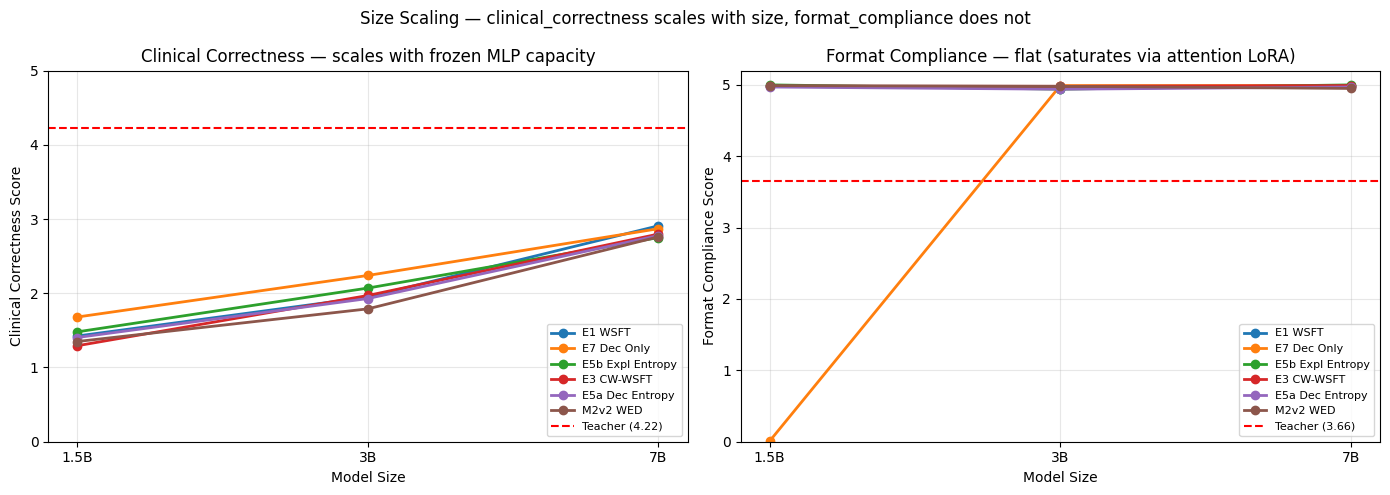

Saved: FIG3_size_scaling.png


In [44]:
# Cell J2: Size scaling — clinical_correctness vs format_compliance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 6 methods by 7B composite_5 (only methods that have all 3 sizes)
top6_methods = flat[flat["size"] == "7B"].sort_values("composite_5", ascending=False)["method"].tolist()
top6 = []
for m in top6_methods:
    if flat[flat["method"] == m]["size"].nunique() == 3:
        top6.append(m)
    if len(top6) == 6: break

cmap = plt.cm.get_cmap("tab10")

for i, m in enumerate(top6):
    mdf = flat[flat["method"] == m].copy()
    mdf["size_idx"] = mdf["size"].map(lambda s: SIZE_ORDER.index(s))
    mdf = mdf.sort_values("size_idx")
    axes[0].plot(mdf["size"].tolist(), mdf["clinical_correctness"].tolist(), 
                 marker="o", linewidth=2, label=m, color=cmap(i))
    axes[1].plot(mdf["size"].tolist(), mdf["format_compliance"].tolist(),
                 marker="o", linewidth=2, label=m, color=cmap(i))

axes[0].axhline(y=teacher_mean["clinical_correctness"], color="red", linestyle="--", label=f"Teacher ({teacher_mean['clinical_correctness']:.2f})")
axes[0].set_title("Clinical Correctness — scales with frozen MLP capacity")
axes[0].set_xlabel("Model Size"); axes[0].set_ylabel("Clinical Correctness Score")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 5)

axes[1].axhline(y=teacher_mean["format_compliance"], color="red", linestyle="--", label=f"Teacher ({teacher_mean['format_compliance']:.2f})")
axes[1].set_title("Format Compliance — flat (saturates via attention LoRA)")
axes[1].set_xlabel("Model Size"); axes[1].set_ylabel("Format Compliance Score")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(alpha=0.3); axes[1].set_ylim(0, 5.2)

plt.suptitle("Size Scaling — clinical_correctness scales with size, format_compliance does not", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG3_size_scaling.png"), dpi=150)
plt.show()
print("Saved: FIG3_size_scaling.png")

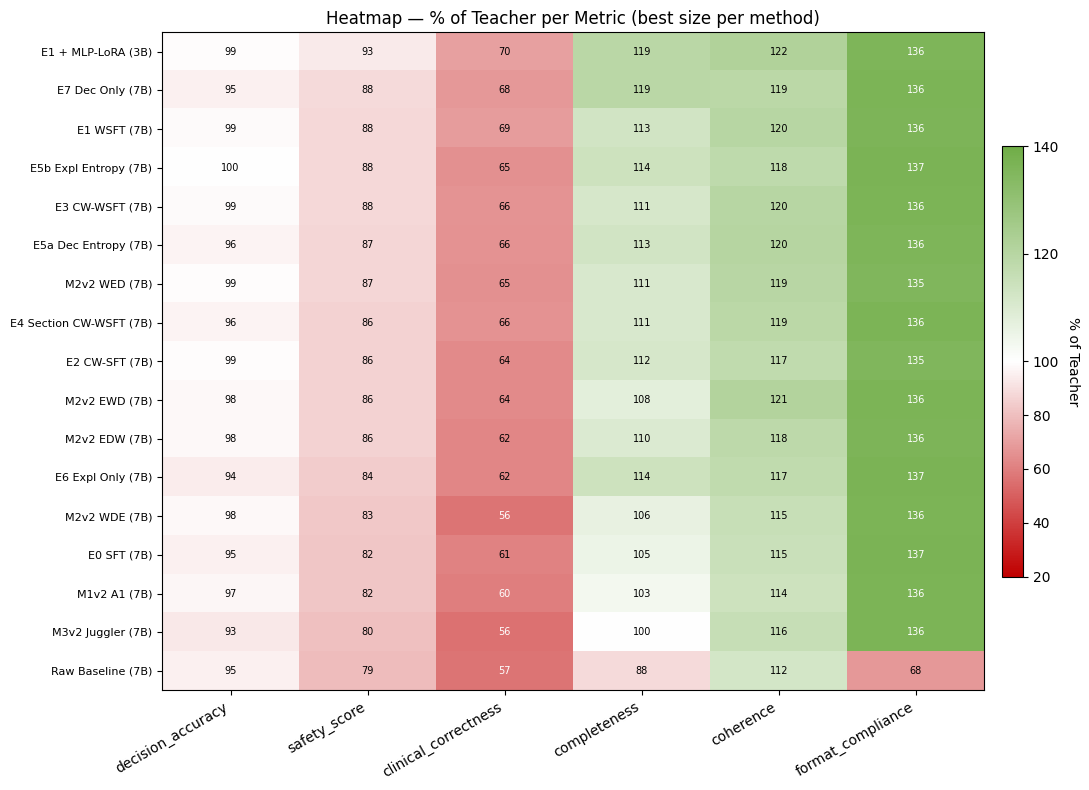

Saved: FIG4_heatmap_pct_teacher.png


In [45]:
# Cell J3: Heatmap — methods × metrics as % of teacher
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

heatmap_rows = []
for method in flat["method"].unique():
    mdf = flat[flat["method"] == method]
    best_idx = mdf["composite_5"].idxmax()
    best_row = mdf.loc[best_idx]
    rec = {"method": f"{method} ({best_row['size']})"}
    for c in METRIC_COLS:
        rec[c] = (best_row[c] / teacher_mean[c] * 100) if teacher_mean[c] > 0 else 0
    rec["composite_5"] = (best_row["composite_5"] / teacher_mean["composite_5"] * 100)
    heatmap_rows.append(rec)

hdf = pd.DataFrame(heatmap_rows).set_index("method").sort_values("composite_5", ascending=False)

fig, ax = plt.subplots(figsize=(11, max(8, len(hdf) * 0.32)))
data = hdf[METRIC_COLS].values

norm = TwoSlopeNorm(vmin=20, vcenter=100, vmax=140)
cmap = LinearSegmentedColormap.from_list("rwg", ["#C00000", "white", "#70AD47"])

im = ax.imshow(data, aspect="auto", cmap=cmap, norm=norm)
ax.set_xticks(range(len(METRIC_COLS)))
ax.set_xticklabels(METRIC_COLS, rotation=30, ha="right")
ax.set_yticks(range(len(hdf)))
ax.set_yticklabels(hdf.index, fontsize=8)

for i in range(len(hdf)):
    for j in range(len(METRIC_COLS)):
        ax.text(j, i, f"{data[i,j]:.0f}", ha="center", va="center", fontsize=7,
                color="black" if 60 < data[i,j] < 130 else "white")

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("% of Teacher", rotation=270, labelpad=15)
ax.set_title("Heatmap — % of Teacher per Metric (best size per method)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "FIG4_heatmap_pct_teacher.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved: FIG4_heatmap_pct_teacher.png")

In [46]:
# Cell J4: Final summary
print("="*100)
print("  FINAL SUMMARY")
print("="*100)
print(f"  Total methods analyzed: {flat['method'].nunique()}")
print(f"  Total method × size combinations: {len(flat)}")
print(f"  Total student score rows: {len(master_df)}")
print(f"  Teacher composite_5: {teacher_mean['composite_5']:.3f}")
print()

top_overall = flat.sort_values("composite_5", ascending=False).iloc[0]
print(f"  🏆 Best overall: {top_overall['method']} {top_overall['size']}")
print(f"     composite_5 = {top_overall['composite_5']:.3f} ({top_overall['pct_of_teacher']:.1f}% of teacher)")

# MLP improvement check
mlp_3b = flat[(flat["family"] == "MLP Ablation") & (flat["size"] == "3B")]
e1_3b = flat[(flat["method"] == "E1 WSFT") & (flat["size"] == "3B")]
if not mlp_3b.empty and not e1_3b.empty:
    print(f"\n  📈 MLP-LoRA improvement at 3B:")
    print(f"     E1 WSFT clinical_correctness: {e1_3b.iloc[0]['clinical_correctness']:.3f}")
    print(f"     E1+MLP clinical_correctness:  {mlp_3b.iloc[0]['clinical_correctness']:.3f}")
    print(f"     Δ = {mlp_3b.iloc[0]['clinical_correctness'] - e1_3b.iloc[0]['clinical_correctness']:+.3f}")

print(f"\n  ✅ All outputs in: {DATA_DIR}")
print(f"     Tables: all_methods_ranked.csv, best_per_family_per_size.csv,")
print(f"             pct_of_teacher_all.csv, form_over_substance_per_metric.csv,")
print(f"             size_scaling.csv, phase1_only_ranked.csv, phase_comparison.csv,")
print(f"             mlp_vs_e1_delta.csv, top_methods_with_ci.csv, failure_cases.json")
print(f"     Plots:  FIG1_composite5_by_method_size.png")
print(f"             FIG2_form_over_substance.png")
print(f"             FIG3_size_scaling.png")
print(f"             FIG4_heatmap_pct_teacher.png")

  FINAL SUMMARY
  Total methods analyzed: 17
  Total method × size combinations: 50
  Total student score rows: 4970
  Teacher composite_5: 3.918

  🏆 Best overall: E1 + MLP-LoRA 3B
     composite_5 = 3.878 (99.0% of teacher)

  📈 MLP-LoRA improvement at 3B:
     E1 WSFT clinical_correctness: 1.949
     E1+MLP clinical_correctness:  2.970
     Δ = +1.021

  ✅ All outputs in: C:\Users\adishalit1\Desktop\kd_project\data
     Tables: all_methods_ranked.csv, best_per_family_per_size.csv,
             pct_of_teacher_all.csv, form_over_substance_per_metric.csv,
             size_scaling.csv, phase1_only_ranked.csv, phase_comparison.csv,
             mlp_vs_e1_delta.csv, top_methods_with_ci.csv, failure_cases.json
     Plots:  FIG1_composite5_by_method_size.png
             FIG2_form_over_substance.png
             FIG3_size_scaling.png
             FIG4_heatmap_pct_teacher.png
